In [1]:
# Regular EDA and plotting libraries
import numpy as np  #tableaux et matrices
import pandas as pd # Permet de manipuler et d'analyser des données sous forme de dataframes, ce qui est similaire à des tableaux Excel
import matplotlib.pyplot as plt  #Permet de créer des visualisations de données, comme des graphiques et des diagrammes.
import seaborn as sns #  Permet de créer des visualisations de données plus complexes et plus attrayantes que celles fournies par matplotlib.

# We want our plots to appear in the notebook
# Afin de visualiser les graphiques dans le notebook
%matplotlib inline 

# Importation des métriques
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


## Models
from sklearn.linear_model import LinearRegression #implémenter le modèle de régression linéaire
from sklearn.ensemble import RandomForestRegressor #implémenter le modèle de forêt d'arbres aléatoires pour la régression
from sklearn.tree import DecisionTreeRegressor #implémenter le modèle d'arbre de décision pour la régression
from sklearn.neighbors import KNeighborsRegressor # pour implémenter le modèle de plus proches voisins (KNN) pour la régression
from sklearn.svm import SVR

## Model evaluators
from sklearn.model_selection import train_test_split, cross_val_score #utilisés pour diviser les données en ensembles d'entraînement et de test, et pour évaluer les modèles à l'aide de la validation croisée.
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV #pour ajuster les hyperparamètres des modèles.

# Print last updated
import time
print(f"Last updated: {time.asctime()}")

Last updated: Tue Apr 14 18:38:01 2026


In [2]:
df = pd.read_csv("../data/real_estate_data.csv") # 'DataFrame' shortened to 'df'  # charger le jeu de données 
df.shape # (rows, columns)  # afficher sa taille

(5653, 12)

In [3]:
df.describe()  # Donne des statistiques descriptives

,prix_num,month_posted,year_posted
count,5.653000e+03,5653.000000,5653.000000
mean,2.602782e+05,5.818857,2025.185919
std,3.889321e+06,3.604828,0.389076
min,0.000000e+00,1.000000,2025.000000
25%,1.350000e+03,2.000000,2025.000000
50%,3.500000e+03,5.000000,2025.000000
75%,2.800000e+05,9.000000,2025.000000
max,2.100000e+08,12.000000,2026.000000


In [4]:
df.info()  # Affiche les informations sur les colonnes et les types de données

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5653 entries, 0 to 5652
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   titre         5653 non-null   object
 1   prix          5653 non-null   object
 2   prix_num      5653 non-null   int64 
 3   categorie     5653 non-null   object
 4   ville         5653 non-null   object
 5   localisation  5653 non-null   object
 6   type          5653 non-null   object
 7   nombre_p      5653 non-null   object
 8   time_posted   5653 non-null   object
 9   date_posted   5653 non-null   object
 10  month_posted  5653 non-null   int64 
 11  year_posted   5653 non-null   int64 
dtypes: int64(3), object(9)
memory usage: 530.1+ KB


In [5]:
df.dtypes  # Donne le type de données de chaque colonne

titre           object
prix            object
prix_num         int64
categorie       object
ville           object
localisation    object
type            object
nombre_p        object
time_posted     object
date_posted     object
month_posted     int64
year_posted      int64
dtype: object

In [6]:
#Afficher la somme des valeurs manquantes
df.isnull().sum()

titre           0
prix            0
prix_num        0
categorie       0
ville           0
localisation    0
type            0
nombre_p        0
time_posted     0
date_posted     0
month_posted    0
year_posted     0
dtype: int64

In [7]:
# Vérifier les doublons
duplicate_rows = df[df.duplicated()]
print("Nombre de lignes dupliquées:", duplicate_rows.shape[0])


Nombre de lignes dupliquées: 21


In [8]:
# Afficher les lignes dupliquées (optionnel)
print("Lignes dupliquées:")
print(duplicate_rows)

Lignes dupliquées:
                                                  titre       prix  prix_num  \
541                                        s+2 a manar1    1000 DT      1000   
553                                       s+2 a manar 2     900 DT       900   
937                                         s+2 manar 1     850 DT       850   
1047                                        s+1 manar 1     900 DT       900   
1801  Maison S+2 meublée et climatisée a louer à ...     160 DT       160   
3367    À LOUER : Un appartement S+2 situé à Cité Wahat    1300 DT      1300   
3783              A louer un s3 aux jardins de carthage    2400 DT      2400   
3833  A Vendre Appartement S+1 Vue Sur Mer à AFH Mre...  330000 DT    330000   
3897  Bel appartement S+2 à vendre à Yasmine Hammame...  295000 DT    295000   
4165  Villa S+2 sur plan avec piscine à vendre à Ham...  370000 DT    370000   
4167  Villa S+3 sur plan avec piscine à vendre à Ham...  420000 DT    420000   
4168  Villa S+2 sur p

In [9]:
# And the top 10
df.head(10) #Cela affichera les 10 premières lignes du DataFrame

,titre,prix,prix_num,categorie,ville,localisation,type,nombre_p,time_posted,date_posted,month_posted,year_posted
0,À louer – Bureaux neufs S+1 et S+2 à Monastir ...,650 DT,650,Location Appartements,Monastir,Monastir,location,S+1,2/4/26 12:37,02-04-26,2,2026
1,S+1 haut standing pour la saison universitaire,850 DT,850,Location Appartements,Monastir,Monastir,location,S+1,8/30/25 10:49,08-30-25,8,2025
2,à vendre s+3 haut standing directement au prom...,350000 DT,350000,Vente Appartements,Monastir,Bekalta,vente,S+3,7/30/25 12:45,07-30-25,7,2025
3,Appartement s+1 vue sur mer pour vacance d’été...,1540 DT,1540,Location de vacances,Monastir,Bekalta,location,S+1,6/17/25 9:41,06-17-25,6,2025
4,Studio mignon estivale,55 DT,55,Location Appartements,Monastir,Monastir,location,S+0,6/10/25 20:59,06-10-25,6,2025
5,S+2 à louer pour longue durée,550 DT,550,Location Appartements,Monastir,Monastir,location,S+2,5/26/25 14:58,05-26-25,5,2025
6,A vendre S+1 lumineux à Folla Monastir,430000 DT,430000,Vente Appartements,Monastir,Monastir,vente,S+1,5/21/25 10:18,05-21-25,5,2025
7,À vendre Superbe S+1 à Folla Monastir,400000 DT,400000,Vente Appartements,Monastir,Monastir,vente,S+1,5/21/25 9:51,05-21-25,5,2025
8,À vendre Superbe S+1 sur mer à Folla Monastir,430000 DT,430000,Vente Appartements,Monastir,Monastir,vente,S+1,5/13/25 11:02,05-13-25,5,2025
9,À vendre – Superbe S+1 à Folla Monastir,400000 DT,400000,Vente Appartements,Monastir,Monastir,vente,S+1,5/10/25 11:23,05-10-25,5,2025


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5653 entries, 0 to 5652
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   titre         5653 non-null   object
 1   prix          5653 non-null   object
 2   prix_num      5653 non-null   int64 
 3   categorie     5653 non-null   object
 4   ville         5653 non-null   object
 5   localisation  5653 non-null   object
 6   type          5653 non-null   object
 7   nombre_p      5653 non-null   object
 8   time_posted   5653 non-null   object
 9   date_posted   5653 non-null   object
 10  month_posted  5653 non-null   int64 
 11  year_posted   5653 non-null   int64 
dtypes: int64(3), object(9)
memory usage: 530.1+ KB


In [11]:
df['prix_num'].unique()

array([      650,       850,    350000,      1540,        55,       550,
          430000,    400000,    560000,      1500,    540000,     40000,
            1000,     80000,    160000,    266000,       450,    348600,
            2000,    264000,    602000,    520000,       680,      1600,
          600000,    460000,       700,       600,       750,       500,
             880,      1300,   1100000,    270000,      1960,      1350,
            2900,      1100,      1400,      1700,      1890,       160,
          175000,    330000,    170000,       900,    190000,    157000,
          374000,    345000,      1250,      1200,       800,      2940,
            2450,      2240,      2800,      2200,       950,      1750,
               0,       400,        80,    210000,      2400,     53000,
          135000,    220000,    420000,    130000,    750000,    110000,
          250000,    305000,    590000,    325000,    164740,    273820,
          278880,    268770,    172820,    275840, 

In [12]:
df['categorie'].unique()

array(['Location Appartements', 'Vente Appartements',
       'Location de vacances', 'Vente Maisons', 'Location Maisons'],
      dtype=object)

In [13]:
df['ville'].unique()

array(['Monastir', 'Sfax', 'Mahdia', 'Bizerte', 'Ben arous', 'Manouba',
       'Kairouan', 'Medenine', 'Ariana', 'Sousse', 'Tunis', 'Nabeul'],
      dtype=object)

In [14]:
df['localisation'].unique()

array(['Monastir', 'Bekalta', 'Sfax Ville', 'Route Menzel Chaker',
       'Sakiet Eddaïer', 'Mahdia', 'Zarzouna', 'Bizerte Nord',
       'Hammam Lif', 'Radès', 'Borj Cedria', 'El Mourouj', 'Mégrine',
       'Ezzahra', 'Medina Jedida', 'Ben Arous', 'Mohamedia',
       'Hammam Chott', 'Denden', 'Manouba Ville', 'Oued Ellil',
       'Kairouan Sud', 'Djerba-Houmt Souk', 'Djerba - Midoun', 'Ennasr',
       'Menzah', 'Ghazela', 'La Soukra', 'Ariana Ville', 'Manar',
       'Borj Louzir', "Jardins D'el Menzah", 'Mnihla', 'Raoued',
       'Chotrana', 'Sidi Thabet', 'Sousse Riadh', 'Sousse Jawhara',
       'Sahloul', 'Hammam Sousse', 'Akouda', 'Sousse Médina', 'Kantaoui',
       'Hergla', 'Kalaâ Sghira', 'Sousse Sidi Abdelhamid', "L'aouina",
       'Ezzouhour', 'Les Berges Du Lac', 'La Marsa', 'Jardin De Carthage',
       'Sidi Daoud', 'Aïn Zaghouan', 'Gammarth', 'Le Bardo', 'Carthage',
       'Mutuelleville', 'Sidi Bou Said', 'Cité El Khadra',
       'El Omrane supérieur', 'La Goulette', 'Centr

In [15]:
df['type'].unique()

array(['location', 'vente'], dtype=object)

In [ ]:
df['nombre_p'].unique()

array([66, 62, 67, 72, 93, 73, 86, 83, 68, 87, 98, 81, 82, 99, 76, 70, 64,
       61, 63, 71, 78, 60, 92, 80, 79, 84, 97, 89, 91, 90, 77, 94, 75, 95,
       69, 74, 65, 96, 88, 85])

In [16]:
df['month_posted'].unique()

array([ 2,  8,  7,  6,  5,  4,  1, 12, 11, 10,  9,  3])

In [17]:
df['year_posted'].unique()

array([2026, 2025])

In [18]:
df['categorie'].value_counts()

categorie
Location Appartements    2341
Vente Appartements       1431
Vente Maisons             975
Location Maisons          697
Location de vacances      209
Name: count, dtype: int64

In [19]:
df['ville'].value_counts()

ville
Nabeul       1832
Tunis        1671
Ariana       1136
Sousse        797
Mahdia        103
Ben arous      62
Monastir       16
Bizerte        15
Manouba        13
Sfax            4
Medenine        3
Kairouan        1
Name: count, dtype: int64

In [20]:
df['type'].value_counts()

type
location    3247
vente       2406
Name: count, dtype: int64

In [21]:
df['nombre_p'].value_counts()

nombre_p
S+2     2041
S+3     1373
S+1     1142
S+4      583
S+0      249
S+5      228
S+6       26
S+7        4
S+9        3
S+8        2
S+25       1
S+11       1
Name: count, dtype: int64

In [22]:
df['year_posted'].value_counts()

year_posted
2025    4602
2026    1051
Name: count, dtype: int64

In [23]:
df['month_posted'].value_counts()

month_posted
2     731
1     719
3     549
5     519
7     463
12    448
11    413
6     404
8     367
10    361
4     354
9     325
Name: count, dtype: int64

In [24]:
df['localisation'].value_counts()

localisation
Hammamet Sud              593
La Marsa                  466
Mrezga                    439
Jardin De Carthage        312
La Soukra                 281
                         ... 
Kairouan Sud                1
Djerba-Houmt Souk           1
Sousse Sidi Abdelhamid      1
Kalaâ Sghira                1
Hammam Ghezèze              1
Name: count, Length: 85, dtype: int64

In [25]:
df['prix_num'].describe()

count    5.653000e+03
mean     2.602782e+05
std      3.889321e+06
min      0.000000e+00
25%      1.350000e+03
50%      3.500000e+03
75%      2.800000e+05
max      2.100000e+08
Name: prix_num, dtype: float64

<Axes: >

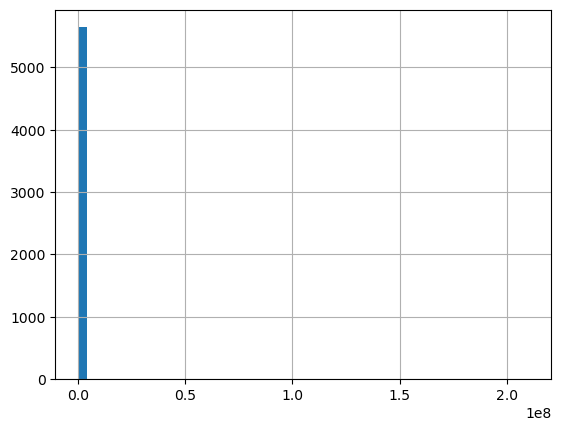

In [26]:
df['prix_num'].hist(bins=50)

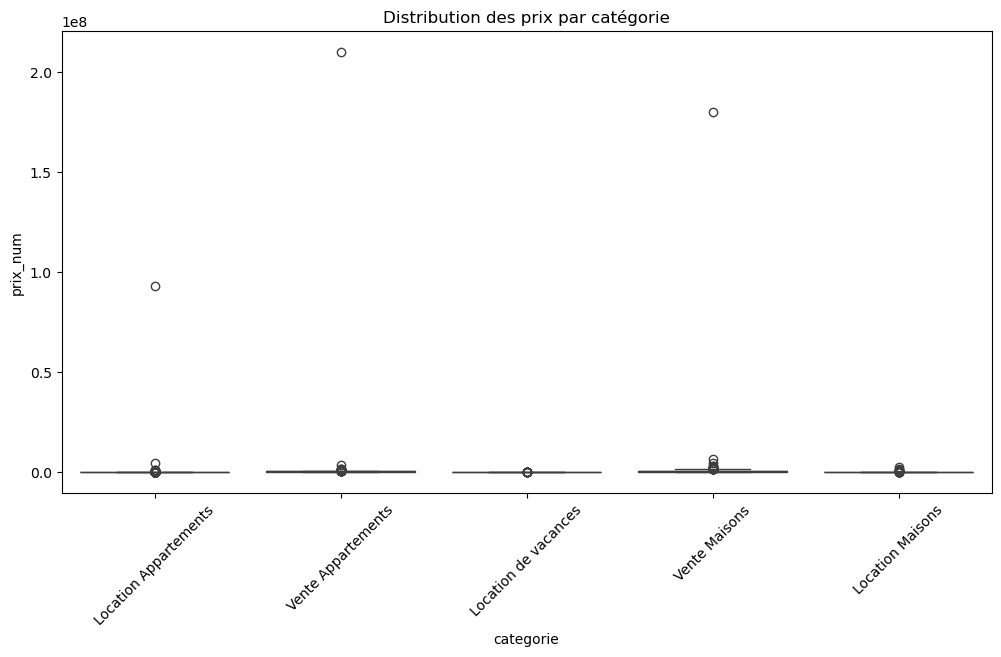

In [27]:
# Visualisation des prix par catégorie
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='categorie', y='prix_num')
plt.title('Distribution des prix par catégorie')
plt.xticks(rotation=45)
plt.show()

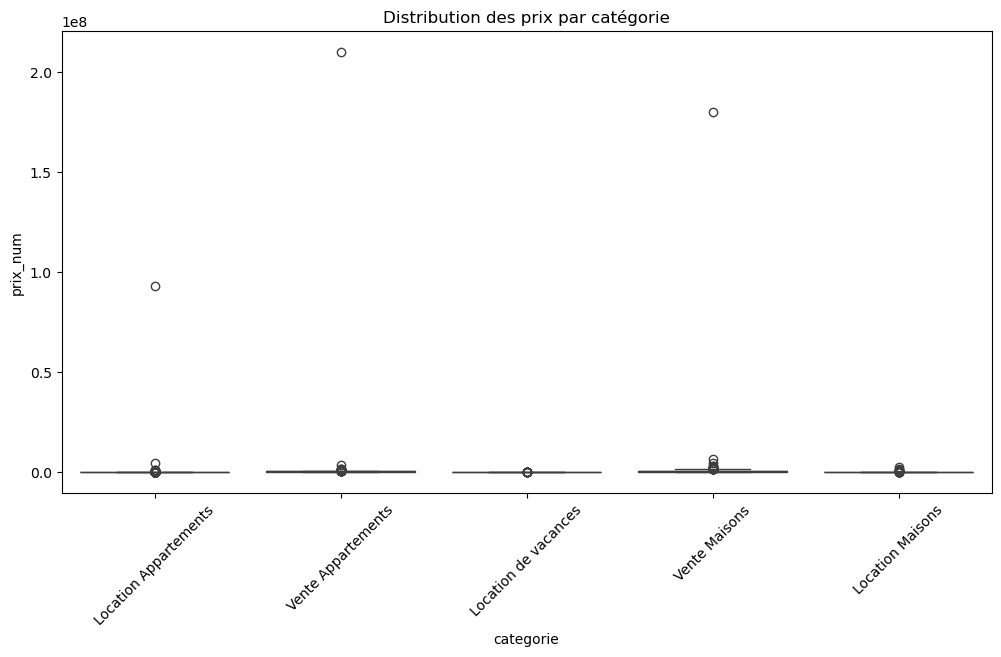

In [28]:
# Visualisation des prix par catégorie
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='categorie', y='prix_num')
plt.title('Distribution des prix par catégorie')
plt.xticks(rotation=45)
plt.show()